## **FILE** **UPLOAD**

In [ ]:
import pandas as pd
df = pd.read_csv("/Breast_cancer_data.csv")

# **HEAD**

In [ ]:
df.head(2)

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0
1,20.57,17.77,132.9,1326.0,0.08474,0


# **SHAPE**

In [ ]:
df.shape

(569, 6)

# **FILE READ**

In [ ]:
df = pd.read_csv("/Breast_cancer_data.csv")

print(df.head())

   mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   diagnosis  
0          0  
1          0  
2          0  
3          0  
4          0  


# **LINEAR REGRESSION**

In [ ]:
from sklearn.linear_model import LinearRegression


df = pd.read_csv("/Breast_cancer_data.csv")


X = df[['mean_radius']]

y = df['mean_area']


model = LinearRegression()
model.fit(X, y)

radius = float(input("Enter Mean Radius: "))

predicted_area = model.predict([[radius]])

print("Mean Radius:", radius)
print("Predicted Mean Area:", predicted_area[0])

Enter Mean Radius: 17.99
Mean Radius: 17.99
Predicted Mean Area: 1035.745259484715


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# **LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression

X = df[['mean_texture']]
y = df['diagnosis']


model = LogisticRegression()
model.fit(X, y)

texture = float(input("Enter Mean Texture: "))

prediction = model.predict([[texture]])

print("Mean Texture:", texture)
print("Predicted Diagnosis:", prediction[0])


if prediction[0] == 0:
    print("Diagnosis: 0")
else:
    print("Diagnosis: 1")

Enter Mean Texture: 56
Mean Texture: 56.0
Predicted Diagnosis: 0
Diagnosis: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# **DECISION TREE**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[
    [
        'mean_radius',
        'mean_texture',
        'mean_perimeter',
        'mean_area'
    ]
]

y = df['mean_smoothness']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

result = pd.DataFrame({
    'Actual Mean Smoothness': y_test.values,
    'Predicted Mean Smoothness': y_pred
})

display(result.head(10))

Mean Squared Error: 0.0002509743116315036
Mean Absolute Error: 0.011955698467504942
R2 Score: -0.21853952493961226


,Actual Mean Smoothness,Predicted Mean Smoothness
0,0.09965,0.092058
1,0.09009,0.097907
2,0.10920,0.088870
3,0.10540,0.092058
4,0.09984,0.096847
5,0.11780,0.097907
6,0.10630,0.097907
7,0.09847,0.097907
8,0.10780,0.092058
9,0.06828,0.093611


Decision Tree Regression Results
---------------------------------
Mean Squared Error: 0.0002568210720326328
Mean Absolute Error: 0.012241604445801822
R2 Score: -0.24692692680282913

Actual vs Predicted:


,Actual Mean Smoothness,Predicted Mean Smoothness
0,0.09965,0.089864
1,0.09009,0.098762
2,0.10920,0.098765
3,0.10540,0.089864
4,0.09984,0.095718
5,0.11780,0.098762
6,0.10630,0.098762
7,0.09847,0.098762
8,0.10780,0.089864
9,0.06828,0.094562


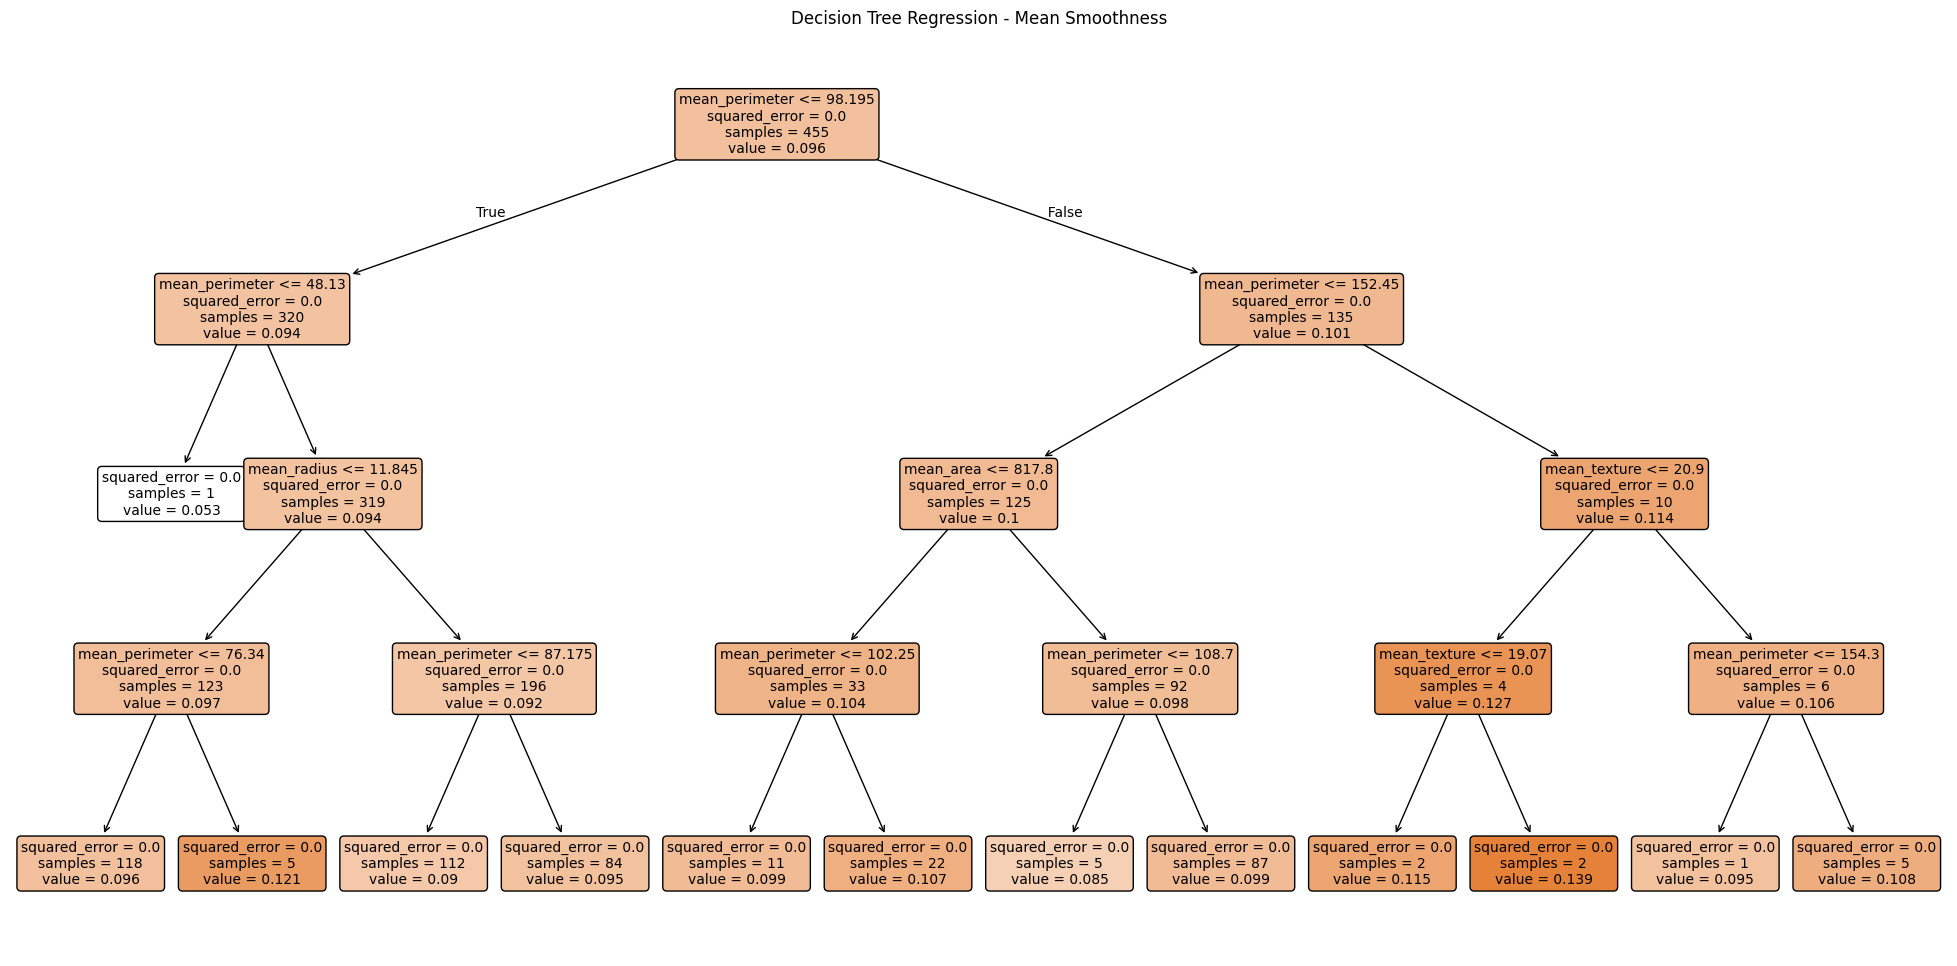

In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[
    [
        'mean_radius',
        'mean_texture',
        'mean_perimeter',
        'mean_area'
    ]
]

y = df['mean_smoothness']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Decision Tree Regression Results")
print("---------------------------------")

print("Mean Squared Error:",
      mean_squared_error(y_test, y_pred))

print("Mean Absolute Error:",
      mean_absolute_error(y_test, y_pred))

print("R2 Score:",
      r2_score(y_test, y_pred))


result = pd.DataFrame({
    'Actual Mean Smoothness': y_test.values,
    'Predicted Mean Smoothness': y_pred
})

print("\nActual vs Predicted:")
display(result.head(10))

plt.figure(figsize=(25, 12))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Regression - Mean Smoothness")
plt.show()

# **RANDOM FOREST**

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


X = df[
    [
        'mean_radius',
        'mean_texture',
        'mean_perimeter',
        'mean_area'
    ]
]

y = df['mean_smoothness']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results")
print("---------------------------------")
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

result = pd.DataFrame({
    'Actual Mean Smoothness': y_test.values,
    'Predicted Mean Smoothness': y_pred
})

print("\nActual vs Predicted:")
display(result.head(10))

Random Forest Regression Results
---------------------------------
Mean Squared Error: 0.00017849835717973688
Mean Absolute Error: 0.00997400614035088
R2 Score: 0.13334834172329235

Actual vs Predicted:


,Actual Mean Smoothness,Predicted Mean Smoothness
0,0.09965,0.094384
1,0.09009,0.100942
2,0.10920,0.107360
3,0.10540,0.101277
4,0.09984,0.098745
5,0.11780,0.104496
6,0.10630,0.097139
7,0.09847,0.095756
8,0.10780,0.107457
9,0.06828,0.083303


   Actual Mean Smoothness  Predicted Mean Smoothness
0                 0.09965                   0.098859
1                 0.09009                   0.100022
2                 0.10920                   0.109857
3                 0.10540                   0.104615
4                 0.09984                   0.102932
5                 0.11780                   0.113053
6                 0.10630                   0.102231
7                 0.09847                   0.098741
8                 0.10780                   0.109717
9                 0.06828                   0.076759


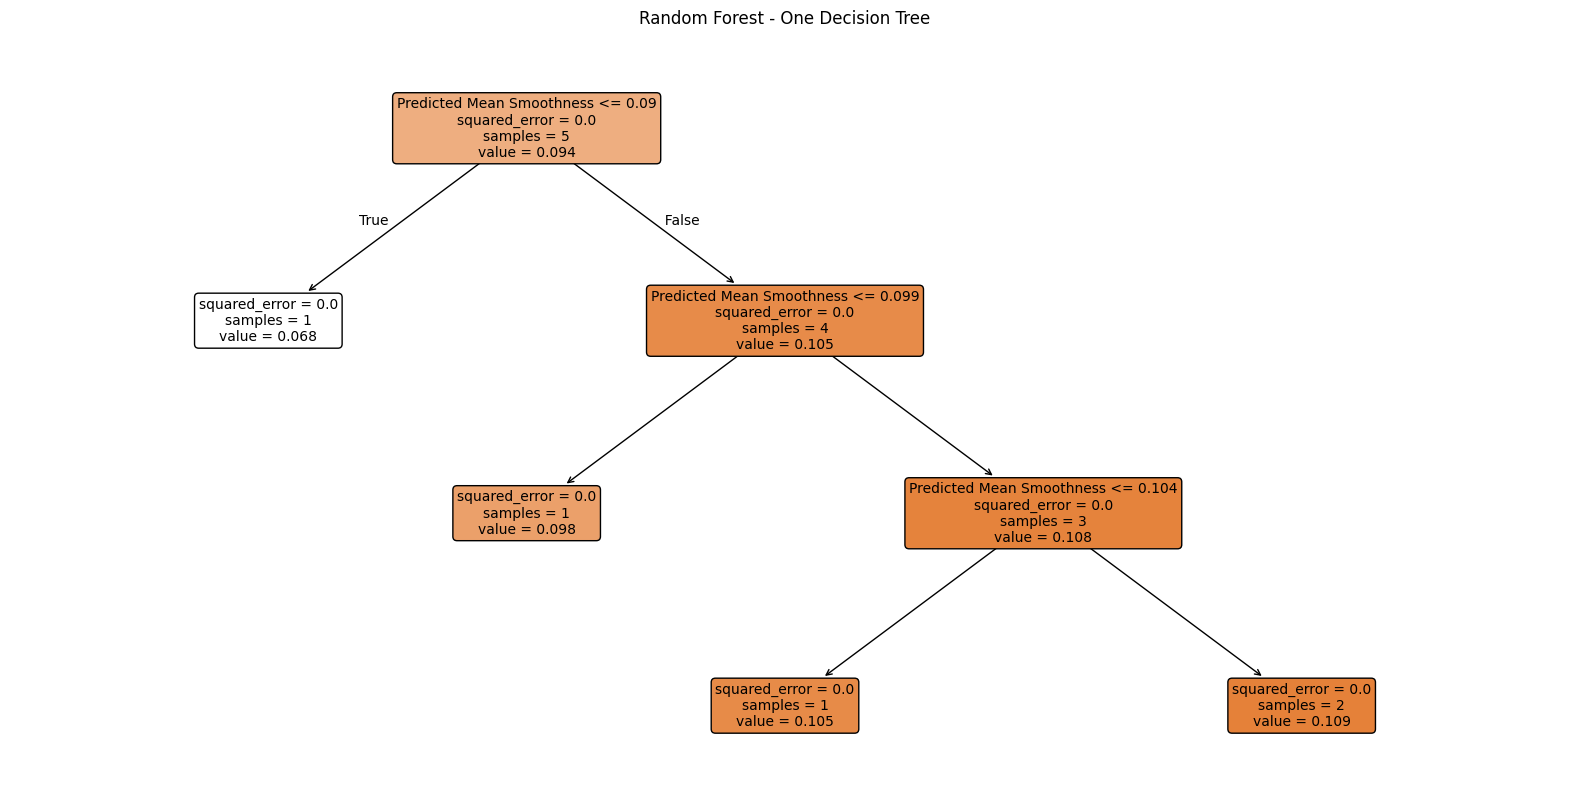

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

data = pd.DataFrame({
    'Actual Mean Smoothness': [
        0.09965, 0.09009, 0.1092, 0.1054, 0.09984,
        0.1178, 0.1063, 0.09847, 0.1078, 0.06828
    ],
    'Predicted Mean Smoothness': [
        0.0943844, 0.1009423, 0.1073603, 0.1012767, 0.0987453,
        0.1044956, 0.0971385, 0.0957561, 0.1074572, 0.0833034
    ]
})

X = data[['Predicted Mean Smoothness']]
y = data['Actual Mean Smoothness']

model = RandomForestRegressor(
    n_estimators=10,
    max_depth=3,
    random_state=42
)

model.fit(X, y)


y_pred = model.predict(X)

result = pd.DataFrame({
    'Actual Mean Smoothness': y,
    'Predicted Mean Smoothness': y_pred
})

print(result)

plt.figure(figsize=(20, 10))

plot_tree(
    model.estimators_[0],
    feature_names=['Predicted Mean Smoothness'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Random Forest - One Decision Tree")
plt.show()

# **SVM(Support Vector Machine)**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


X = df[['mean_radius',
        'mean_texture',
        'mean_perimeter',
        'mean_area']]

y = df['mean_smoothness']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

result = pd.DataFrame({
    'Actual Mean Smoothness': y_test.values,
    'Predicted Mean Smoothness': y_pred
})

display(result.head(10))

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

,Actual Mean Smoothness,Predicted Mean Smoothness
0,0.09965,0.093224
1,0.09009,0.088025
2,0.10920,0.101088
3,0.10540,0.108260
4,0.09984,0.108023
5,0.11780,0.089926
6,0.10630,0.105170
7,0.09847,0.093087
8,0.10780,0.128789
9,0.06828,0.081620


Mean Squared Error: 0.0001594310310860566
Mean Absolute Error: 0.009218672773562574
R2 Score: 0.22592471071111087


# **K-Nearest Neighbors.(KNN)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

data = pd.read_csv("/Breast_cancer_data.csv")
X = data.drop('mean_smoothness', axis=1)
y = data['mean_smoothness']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])
print("R2 Score:", r2_score(y_test, y_pred))

Actual: [0.09965 0.09009 0.1092  0.1054  0.09984 0.1178  0.1063  0.09847 0.1078
 0.06828]
Predicted: [0.093784 0.0941   0.1051   0.086934 0.095214 0.099918 0.102966 0.095678
 0.103508 0.084652]
R2 Score: -0.20391353410021407


# **Naive_Bayes**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])
print("Accuracy:", accuracy_score(y_test, y_pred))

Actual: [1 0 0 1 1 0 0 0 1 1]
Predicted: [1 0 0 1 1 0 0 0 1 1]
Accuracy: 0.9385964912280702
